# Notebook 03 - Random Forest Analysis

This notebook is going to use random forest in order to find feature importance to asnwer **RQ2: How do environmental variables vary with occupancy?**


## Part 0 - Setup

In [8]:
!pip install sparqlwrapper pandas

In [1]:
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

ENDPOINT = "http://136.113.132.176:7001"


def execute_query(query):
    sparql = SPARQLWrapper(ENDPOINT)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    sparql.setMethod("POST")
    sparql.setTimeout(180)
    
    results = sparql.query().convert()
    vars_ = results["head"]["vars"]
    bindings = results["results"]["bindings"]
    
    data = []
    for row in bindings:
        entry = {}
        for var in vars_:
            entry[var] = row[var]["value"] if var in row else None
        data.append(entry)
    
    return pd.DataFrame(data)

try:
    test = execute_query("SELECT * WHERE {} LIMIT 1")
    print("Connection to QLever established:", ENDPOINT)
except:
    print("Connection to QLever failed.")

Connection to QLever established: http://136.113.132.176:7001


In [2]:
df_mco_occupancy = pd.read_pickle("df_mco_occupancy.pkl")
print("Loaded df_mco_occupancy.pkl")

df_thingy_occupancy = pd.read_pickle("df_thingy_occupancy.pkl")
print("Loaded df_thingy_occupancy.pkl")

Loaded df_mco_occupancy.pkl
Loaded df_thingy_occupancy.pkl


## Part 1 - MCO

In [3]:
mco_sensors = {
    "mcomulti01": "NU-11A-66",
    "mcomulti02": "NU-11A-37",
    "mcomulti03": "NU-11A-48",
    "mcomulti04": "NU-11A-46",
    "mcomulti05": "NU-11A-58",
    "mcomulti06": "NU-11A-56"
}

mco_properties = [
    "Temperature",
    "Humidity",
    "eCO2",
    "Illuminance",
    "ParticulateMatter_2_5",
    "VOCLevel"
]

#a resusable function that takes the takes the property name, sensor name and floor number and builds the correct IRI
def query_property(prop_name, sensor, floor):
    return f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>
SELECT ?val ?timestamp
WHERE {{
    nu:{prop_name}_{sensor}_floor{floor} saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val ;
        saref:hasTimestamp ?timestamp .
}}
ORDER BY ?timestamp
"""

#for each sensor builds a dataframe with all properties as columns
dfs_mco = []
for sensor, room in mco_sensors.items():
    print(f"Querying {sensor}...")
    df_sensor = None
    for prop_name in mco_properties:
        df = execute_query(query_property(prop_name, sensor, 11))
        if len(df) > 0:
            df["timestamp"] = pd.to_datetime(df["timestamp"])
            df["val"] = pd.to_numeric(df["val"], errors="coerce")
            df = df[["timestamp", "val"]].rename(columns={"val": prop_name})
            if df_sensor is None:
                df_sensor = df
            else:
                df_sensor = df_sensor.merge(df, on="timestamp", how="outer") #how="outer" keeps all timestamps even when individual property readings are missing

    #labels for clarity after concantaneation
    df_sensor["sensor"] = sensor
    df_sensor["room"] = room
    dfs_mco.append(df_sensor)
    print(f"  {sensor}: {len(df_sensor)} rows")

df_mco_features = pd.concat(dfs_mco, ignore_index=True)
print(f"\nTotal MCO feature rows: {len(df_mco_features)}")

Querying mcomulti01...
  mcomulti01: 22816 rows
Querying mcomulti02...
  mcomulti02: 22947 rows
Querying mcomulti03...
  mcomulti03: 22988 rows
Querying mcomulti04...
  mcomulti04: 19481 rows
Querying mcomulti05...
  mcomulti05: 22975 rows
Querying mcomulti06...
  mcomulti06: 22820 rows

Total MCO feature rows: 134027


In [ ]:
#features are merged with occuoancy label from .pkl
df_mco_labels = df_mco_occupancy[["timestamp", "sensor", "occupied"]].copy()
df_mco = df_mco_features.merge(df_mco_labels, on=["timestamp", "sensor"], how="inner")
print(f"MCO merged dataset: {len(df_mco)} rows")
print(f"Occupancy rate: {df_mco['occupied'].mean():.2%}")

In [12]:
df_mco.to_pickle("df_mco_raw.pkl")
print("Saved df_mco_raw.pkl")

Saved df_mco_raw.pkl


In [13]:
#0s are replaced with NaN if not possible
cols_no_zero_mco = ["Humidity"]
df_mco[cols_no_zero_mco] = df_mco[cols_no_zero_mco].replace(0, np.nan)

#rows with at least one NaN are dropped
feature_cols_mco = [p for p in mco_properties if p != "eCO2"]
df_mco_rf = df_mco[feature_cols_mco + ["occupied"]].dropna()

print(f"Rows after cleaning: {len(df_mco_rf)}")
print(f"Occupancy rate after cleaning: {df_mco_rf['occupied'].mean():.2%}")

Rows after cleaning: 132309
Occupancy rate after cleaning: 11.49%


In [14]:
X = df_mco_rf[feature_cols_mco]
y = df_mco_rf["occupied"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y #80% train , 20% test, stratify=y ensures both sets have the same occypancy rate
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

rf_mco = RandomForestClassifier( #uses 100 trees, the deafault by sklearn
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_mco.fit(X_train, y_train)
y_pred = rf_mco.predict(X_test)

print("\nMCO Classification Report:")
print(classification_report(y_test, y_pred))

Training Features Shape: (105847, 5)
Testing Features Shape: (26462, 5)

MCO Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95     23421
           1       0.71      0.49      0.58      3041

    accuracy                           0.92     26462
   macro avg       0.82      0.73      0.77     26462
weighted avg       0.91      0.92      0.91     26462



MCO Feature Importances:
Variable: Illuminance                    Importance: 0.47
Variable: Temperature                    Importance: 0.19
Variable: Humidity                       Importance: 0.17
Variable: VOCLevel                       Importance: 0.13
Variable: ParticulateMatter_2_5          Importance: 0.03


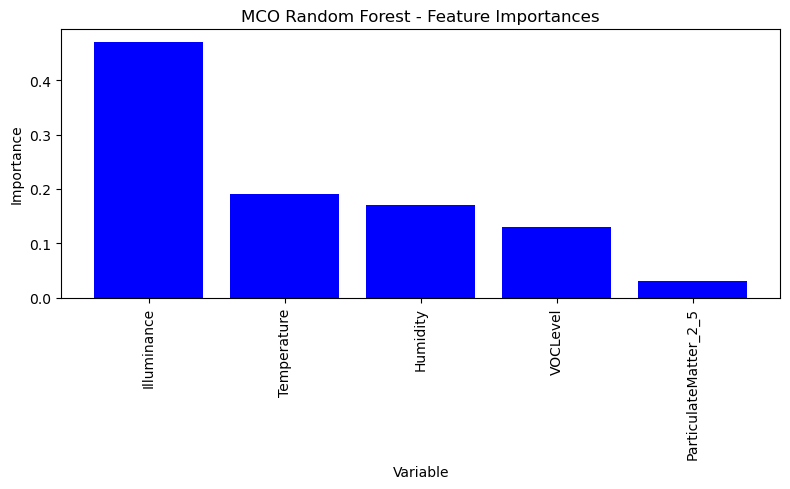

In [15]:
importances = list(rf_mco.feature_importances_)
feature_importances = [(feature, round(importance, 2)) 
                       for feature, importance in zip(feature_cols_mco, importances)]
feature_importances = sorted(feature_importances, key=lambda x: x[1], reverse=True)

print("MCO Feature Importances:")
[print('Variable: {:30} Importance: {}'.format(*pair)) for pair in feature_importances]

# Bar chart
x_values = list(range(len(importances)))
plt.figure(figsize=(8, 5))
plt.bar(x_values, 
        [imp for _, imp in feature_importances], 
        color="blue")
plt.xticks(x_values, 
           [feat for feat, _ in feature_importances], 
           rotation="vertical")
plt.ylabel("Importance")
plt.xlabel("Variable")
plt.title("MCO Random Forest - Feature Importances")
plt.tight_layout()
plt.show()

## Part 2 - Thingy 

In [16]:
thingy_rooms_clean = {
    "NU-10A-13": ["thingy012_floor10", "thingy017_floor10"],
    "NU-11A-29": ["thingy035_floor11", "thingy037_floor11", "thingy038_floor11"],
    "NU-11A-46": ["thingy055_floor11", "thingy056_floor11"],
    "NU-11A-56": ["thingy051_floor11", "thingy052_floor11"],
    "NU-11A-65": ["thingy001_floor11", "thingy021_floor11", "thingy022_floor11",
                  "thingy023_floor11", "thingy024_floor11", "thingy025_floor11",
                  "thingy026_floor11", "thingy027_floor11", "thingy028_floor11"],
    "NU-12A-48": ["thingy047_floor12"],
    "NU-12A-55": ["thingy065_floor12", "thingy068_floor12"],
    "NU-12A-56": ["thingy041_floor12", "thingy042_floor12"],
    "NU-12A-57": ["thingy061_floor12", "thingy062_floor12"],
    "NU-12A-58": ["thingy043_floor12", "thingy044_floor12"],
    "NU-12A-60": ["thingy045_floor12", "thingy046_floor12"],
}

thingy_properties = [
    "Temperature",
    "Humidity",
    "eCO2",
    "TVOC",
    "ColorB",
    "ColorC",
    "ColorR",
    "ColorG",
    "Pressure"
]

def query_thingy_property(prop_name, sensor):
    return f"""
PREFIX saref: <https://saref.etsi.org/core/>
PREFIX nu: <https://vu.nl/nu-building#>
SELECT ?val ?timestamp
WHERE {{
    nu:{prop_name}_{sensor} saref:hasPropertyValue ?pv .
    ?pv saref:hasValue ?val ;
        saref:hasTimestamp ?timestamp .
}}
ORDER BY ?timestamp
"""

dfs_thingy = []
for room, sensors in thingy_rooms_clean.items():
    print(f"Querying {room}...")
    df_room = None
    
    for prop_name in thingy_properties: #collects for each room all sensor reading per property
        dfs_prop = []
        for sensor in sensors:
            df = execute_query(query_thingy_property(prop_name, sensor))
            if len(df) > 0:
                df["timestamp"] = pd.to_datetime(df["timestamp"])
                df["val"] = pd.to_numeric(df["val"], errors="coerce")
                dfs_prop.append(df[["timestamp", "val"]])
        
        if dfs_prop: #calculates the median based on all readings per property
            df_prop = pd.concat(dfs_prop)
            df_prop = df_prop.groupby("timestamp")["val"].median().reset_index()
            df_prop = df_prop.rename(columns={"val": prop_name})
            
            if df_room is None:
                df_room = df_prop
            else:
                df_room = df_room.merge(df_prop, on="timestamp", how="outer")
    
    if df_room is not None:
        df_room["room"] = room
        dfs_thingy.append(df_room)
        print(f"  {room}: {len(df_room)} rows")

df_thingy_features = pd.concat(dfs_thingy, ignore_index=True)
print(f"\nTotal Thingy feature rows: {len(df_thingy_features)}")

Querying NU-10A-13...
  NU-10A-13: 10251 rows
Querying NU-11A-29...
  NU-11A-29: 29797 rows
Querying NU-11A-46...
  NU-11A-46: 25414 rows
Querying NU-11A-56...
  NU-11A-56: 13222 rows
Querying NU-11A-65...
  NU-11A-65: 25116 rows
Querying NU-12A-48...
  NU-12A-48: 12822 rows
Querying NU-12A-55...
  NU-12A-55: 28537 rows
Querying NU-12A-56...
  NU-12A-56: 23866 rows
Querying NU-12A-57...
  NU-12A-57: 28574 rows
Querying NU-12A-58...
  NU-12A-58: 19268 rows
Querying NU-12A-60...
  NU-12A-60: 28159 rows

Total Thingy feature rows: 245026


In [17]:
df_thingy_labels = df_thingy_occupancy[["timestamp", "room", "occupied"]].copy()
df_thingy = df_thingy_features.merge(df_thingy_labels, on=["timestamp", "room"], how="inner")
print(f"Thingy merged dataset: {len(df_thingy)} rows")
print(f"Occupancy rate: {df_thingy['occupied'].mean():.2%}")

Thingy merged dataset: 244738 rows
Occupancy rate: 12.70%


In [18]:
df_thingy.to_pickle("df_thingy_raw.pkl")
print("Saved df_thingy_raw.pkl")

Saved df_thingy_raw.pkl


In [19]:
cols_no_zero_thingy = ["Humidity", "eCO2", "Pressure"]
df_thingy[cols_no_zero_thingy] = df_thingy[cols_no_zero_thingy].replace(0, np.nan)

feature_cols_thingy = thingy_properties
df_thingy_rf = df_thingy[feature_cols_thingy + ["occupied"]].dropna()

print(f"Rows after cleaning: {len(df_thingy_rf)}")
print(f"Occupancy rate after cleaning: {df_thingy_rf['occupied'].mean():.2%}")

Rows after cleaning: 218471
Occupancy rate after cleaning: 13.70%


In [20]:
X = df_thingy_rf[feature_cols_thingy]
y = df_thingy_rf["occupied"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

rf_thingy = RandomForestClassifier( #uses 100 trees, the deafault by sklearn
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_thingy.fit(X_train, y_train)
y_pred_thingy = rf_thingy.predict(X_test)

print("\nThingy Classification Report:")
print(classification_report(y_test, y_pred_thingy))

Training Features Shape: (174776, 9)
Testing Features Shape: (43695, 9)

Thingy Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     37709
           1       0.91      0.67      0.77      5986

    accuracy                           0.95     43695
   macro avg       0.93      0.83      0.87     43695
weighted avg       0.94      0.95      0.94     43695



Thingy Feature Importances:
Variable: Humidity                       Importance: 0.34
Variable: Temperature                    Importance: 0.18
Variable: Pressure                       Importance: 0.11
Variable: eCO2                           Importance: 0.07
Variable: TVOC                           Importance: 0.07
Variable: ColorR                         Importance: 0.07
Variable: ColorB                         Importance: 0.06
Variable: ColorG                         Importance: 0.06
Variable: ColorC                         Importance: 0.04


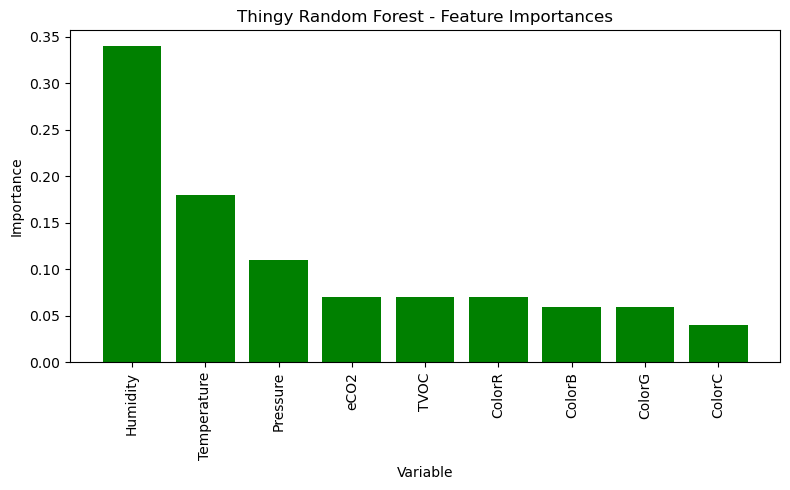

In [21]:
importances_thingy = list(rf_thingy.feature_importances_)
feature_importances_thingy = [(feature, round(importance, 2)) 
                               for feature, importance in zip(feature_cols_thingy, importances_thingy)]
feature_importances_thingy = sorted(feature_importances_thingy, key=lambda x: x[1], reverse=True)

print("Thingy Feature Importances:")
[print('Variable: {:30} Importance: {}'.format(*pair)) for pair in feature_importances_thingy]

# Bar chart
x_values = list(range(len(importances_thingy)))
plt.figure(figsize=(8, 5))
plt.bar(x_values, 
        [imp for _, imp in feature_importances_thingy], 
        color="green")
plt.xticks(x_values, 
           [feat for feat, _ in feature_importances_thingy], 
           rotation="vertical")
plt.ylabel("Importance")
plt.xlabel("Variable")
plt.title("Thingy Random Forest - Feature Importances")
plt.tight_layout()
plt.show()